# 📊 Superstore Dataset Analysis


In [1]:
# Import libraries and load dataset
import pandas as pd
import numpy as np

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load the dataset (Kaggle path)
df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', encoding='latin1')

print(f" Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

 Dataset loaded: 9994 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [2]:
# Dataset structure and info
print("="*60)
print("DATASET INFORMATION")
print("="*60)

# Basic info
print(f"\n Shape: {df.shape}")
print(f" Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data types
print("\n COLUMN DATA TYPES:")
print(df.dtypes)

# Check for missing values
print("\n MISSING VALUES:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found!")

# Check duplicates
duplicates = df.duplicated().sum()
print(f"\n Duplicate rows: {duplicates}")

DATASET INFORMATION

 Shape: (9994, 21)
 Memory: 9.21 MB

 COLUMN DATA TYPES:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

 MISSING VALUES:
No missing values found!

 Duplicate rows: 0


In [3]:
# Summary statistics
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

# Numerical columns
print("\n NUMERICAL COLUMNS:")
display(df.describe())

# Categorical columns
print("\n CATEGORICAL COLUMNS:")
display(df.describe(include=['object']))

# Unique values in categorical columns
print("\n UNIQUE VALUES COUNT:")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols[:5]:  # Show first 5 categorical columns
    print(f"  {col}: {df[col].nunique()} unique values")

STATISTICAL SUMMARY

 NUMERICAL COLUMNS:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000



 CATEGORICAL COLUMNS:


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48



 UNIQUE VALUES COUNT:
  Order ID: 5009 unique values
  Order Date: 1237 unique values
  Ship Date: 1334 unique values
  Ship Mode: 4 unique values
  Customer ID: 793 unique values


# 🔧 Task 2: Data Cleaning



In [4]:
# Check for missing values and data types
print("="*60)
print("DATA QUALITY CHECK - BEFORE CLEANING")
print("="*60)

# Check missing values
print("\n MISSING VALUES:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Count'] > 0]
print(missing_df if len(missing_df) > 0 else " No missing values found!")

# Check data types
print("\n CURRENT DATA TYPES:")
print(df.dtypes)

# Check for duplicates
print(f"\n Duplicate rows: {df.duplicated().sum()}")

DATA QUALITY CHECK - BEFORE CLEANING

 MISSING VALUES:
 No missing values found!

 CURRENT DATA TYPES:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

 Duplicate rows: 0


In [5]:
# Handle missing values and convert data types
print("="*60)
print("CLEANING PROCESS")
print("="*60)

# Create a clean copy
df_clean = df.copy()

# 1. Handle missing values
print("\n1️ HANDLING MISSING VALUES:")
if df_clean.isnull().sum().sum() > 0:
    # Fill numerical columns with median
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"   ✓ Filled '{col}' with median: {median_val:.2f}")
    
    # Fill categorical columns with mode
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"   ✓ Filled '{col}' with mode: {mode_val}")
else:
    print("   ✓ No missing values to handle")

# 2. Remove duplicates
print("\n2️ REMOVING DUPLICATES:")
duplicates_before = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f"   ✓ Removed {duplicates_before} duplicate rows")

# 3. Convert date columns
print("\n3️ CONVERTING DATE COLUMNS:")
date_cols = [col for col in df_clean.columns if 'Date' in col or 'date' in col]
for col in date_cols:
    try:
        df_clean[col] = pd.to_datetime(df_clean[col])
        print(f"   ✓ Converted '{col}' to datetime")
    except:
        print(f"    Could not convert '{col}'")

# 4. Fix Postal Code (should be string, not number)
if 'Postal Code' in df_clean.columns:
    df_clean['Postal Code'] = df_clean['Postal Code'].astype(str)
    print("   ✓ Converted 'Postal Code' to string")

print("\n Cleaning completed!")

CLEANING PROCESS

1️ HANDLING MISSING VALUES:
   ✓ No missing values to handle

2️ REMOVING DUPLICATES:
   ✓ Removed 0 duplicate rows

3️ CONVERTING DATE COLUMNS:
   ✓ Converted 'Order Date' to datetime
   ✓ Converted 'Ship Date' to datetime
   ✓ Converted 'Postal Code' to string

 Cleaning completed!


In [6]:
# Verify cleaning results
print("="*60)
print("DATA QUALITY CHECK - AFTER CLEANING")
print("="*60)

# Check missing values again
print("\n MISSING VALUES (should be 0):")
remaining_missing = df_clean.isnull().sum().sum()
print(f"   Total missing: {remaining_missing}")

# Check data types after conversion
print("\n UPDATED DATA TYPES:")
print(df_clean.dtypes)

# Check dataset shape
print(f"\n Final dataset shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

# Display sample of cleaned data
print("\n SAMPLE OF CLEANED DATA (first 5 rows):")
df_clean.head()

# Save cleaned dataset
df_clean.to_csv('superstore_cleaned.csv', index=False)
print("\n Cleaned dataset saved as 'superstore_cleaned.csv'")

print("\n" + "="*60)
print(" TASK 2 COMPLETED - Ready for Task 3")
print("="*60)

DATA QUALITY CHECK - AFTER CLEANING

 MISSING VALUES (should be 0):
   Total missing: 0

 UPDATED DATA TYPES:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

 Final dataset shape: 9994 rows, 21 columns

 SAMPLE OF CLEANED DATA (first 5 rows):

 Cleaned dataset saved as 'superstore_cleaned.csv'

 TASK 2 COMPLETED - Ready for Task 3


# 🔧 Task 3: Feature Engineering


In [7]:
# First, make sure Order Date is datetime type (from Task 2)
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])

# Extract month (returns number 1-12)
df_clean['Month'] = df_clean['Order Date'].dt.month

# Extract year (returns 2021, 2022, etc.)
df_clean['Year'] = df_clean['Order Date'].dt.year

# Extract month name (January, February, etc.)
df_clean['Month Name'] = df_clean['Order Date'].dt.month_name()

# Extract day of week (Monday, Tuesday, etc.)
df_clean['Day of Week'] = df_clean['Order Date'].dt.day_name()

# View results
print("New date columns added:")
print(df_clean[['Order Date', 'Year', 'Month', 'Month Name', 'Day of Week']].head())

New date columns added:
  Order Date  Year  Month Month Name Day of Week
0 2016-11-08  2016     11   November     Tuesday
1 2016-11-08  2016     11   November     Tuesday
2 2016-06-12  2016      6       June      Sunday
3 2015-10-11  2015     10    October      Sunday
4 2015-10-11  2015     10    October      Sunday


In [8]:
# Create Profit Margin (profit as percentage of sales)
# Formula: (Profit / Sales) × 100
df_clean['Profit Margin (%)'] = (df_clean['Profit'] / df_clean['Sales']) * 100

# Create Discount Impact (how much money discounted)
df_clean['Discount Amount'] = df_clean['Sales'] * df_clean['Discount']

# Create Average Price Per Item
df_clean['Avg Price Per Unit'] = df_clean['Sales'] / df_clean['Quantity']

# Create Profit Per Item
df_clean['Profit Per Unit'] = df_clean['Profit'] / df_clean['Quantity']

# Round to 2 decimal places for cleaner look
df_clean['Profit Margin (%)'] = df_clean['Profit Margin (%)'].round(2)
df_clean['Avg Price Per Unit'] = df_clean['Avg Price Per Unit'].round(2)

# View results
print("New calculated columns:")
print(df_clean[['Sales', 'Profit', 'Profit Margin (%)', 'Discount Amount']].head())

New calculated columns:
      Sales    Profit  Profit Margin (%)  Discount Amount
0  261.9600   41.9136              16.00         0.000000
1  731.9400  219.5820              30.00         0.000000
2   14.6200    6.8714              47.00         0.000000
3  957.5775 -383.0310             -40.00       430.909875
4   22.3680    2.5164              11.25         4.473600


In [9]:
# Check 1: Profit Margin should be between -100% and 100%
print("Checking Profit Margin range:")
print(f"Min margin: {df_clean['Profit Margin (%)'].min():.2f}%")
print(f"Max margin: {df_clean['Profit Margin (%)'].max():.2f}%")

# Check 2: Look for impossible values
print("\nChecking for errors:")
invalid_margins = df_clean[df_clean['Profit Margin (%)'] > 100]
print(f"Rows with margin > 100%: {len(invalid_margins)}")

# Check 3: Spot check a few rows manually
print("\nSpot check - 5 random rows:")
sample = df_clean[['Sales', 'Profit', 'Quantity', 'Profit Margin (%)', 'Avg Price Per Unit']].sample(5)
print(sample)



Checking Profit Margin range:
Min margin: -275.00%
Max margin: 50.00%

Checking for errors:
Rows with margin > 100%: 0

Spot check - 5 random rows:
       Sales   Profit  Quantity  Profit Margin (%)  Avg Price Per Unit
898   46.960  22.5408         8              48.00                5.87
1632  10.368   3.6288         2              35.00                5.18
3513  17.760   5.5500         3              31.25                5.92
4834  39.920  13.4730         5              33.75                7.98
9232  94.680  31.2444         9              33.00               10.52


# Task 4: GroupBy & Aggregation

In [10]:
# Group by Category and sum Sales
sales_by_category = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("="*50)
print("TOTAL SALES BY CATEGORY")
print("="*50)
print(sales_by_category)

# Add dollar formatting for readability
print("\nWith formatting:")
for category, sales in sales_by_category.items():
    print(f"{category:20}: ${sales:,.2f}")

TOTAL SALES BY CATEGORY
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

With formatting:
Technology          : $836,154.03
Furniture           : $741,999.80
Office Supplies     : $719,047.03


In [11]:
# Group by Region and sum Profit
profit_by_region = df_clean.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print("="*50)
print("TOTAL PROFIT BY REGION")
print("="*50)
print(profit_by_region)

# Identify losing regions (negative profit)
print("\nRegions with losses:")
losing_regions = profit_by_region[profit_by_region < 0]
if len(losing_regions) > 0:
    print(losing_regions)
else:
    print("All regions profitable!")

TOTAL PROFIT BY REGION
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

Regions with losses:
All regions profitable!


In [12]:
# Group by Customer, sum Sales, get top 5
top_customers = df_clean.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

print("="*50)
print("TOP 5 CUSTOMERS BY SALES")
print("="*50)
for i, (customer, sales) in enumerate(top_customers.items(), 1):
    print(f"{i}. {customer:25}: ${sales:,.2f}")

# Also show their profit (important!)
print("\nProfit from top customers:")
for customer in top_customers.index:
    profit = df_clean[df_clean['Customer Name'] == customer]['Profit'].sum()
    print(f"{customer:25}: ${profit:,.2f}")

TOP 5 CUSTOMERS BY SALES
1. Sean Miller              : $25,043.05
2. Tamara Chand             : $19,052.22
3. Raymond Buch             : $15,117.34
4. Tom Ashbrook             : $14,595.62
5. Adrian Barton            : $14,473.57

Profit from top customers:
Sean Miller              : $-1,980.74
Tamara Chand             : $8,981.32
Raymond Buch             : $6,976.10
Tom Ashbrook             : $4,703.79
Adrian Barton            : $5,444.81


In [13]:
# Group by Year and Month, sum Sales
monthly_sales = df_clean.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

print("="*50)
print("MONTHLY SALES TREND")
print("="*50)
print(monthly_sales)

# Find best and worst months
print("\n" + "="*50)
print("BEST AND WORST MONTHS")
print("="*50)

best_month = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
worst_month = monthly_sales.loc[monthly_sales['Sales'].idxmin()]

print(f"Best month: {best_month['Year']}-{best_month['Month']} with ${best_month['Sales']:,.2f}")
print(f"Worst month: {worst_month['Year']}-{worst_month['Month']} with ${worst_month['Sales']:,.2f}")

# Calculate month-over-month growth
monthly_sales['Previous Month Sales'] = monthly_sales['Sales'].shift(1)
monthly_sales['Growth (%)'] = ((monthly_sales['Sales'] - monthly_sales['Previous Month Sales']) / monthly_sales['Previous Month Sales']) * 100

print("\nMonth-over-month growth (first 5 months):")
print(monthly_sales[['Year', 'Month', 'Sales', 'Growth (%)']].head())

MONTHLY SALES TREND
    Year  Month        Sales
0   2014      1   14236.8950
1   2014      2    4519.8920
2   2014      3   55691.0090
3   2014      4   28295.3450
4   2014      5   23648.2870
5   2014      6   34595.1276
6   2014      7   33946.3930
7   2014      8   27909.4685
8   2014      9   81777.3508
9   2014     10   31453.3930
10  2014     11   78628.7167
11  2014     12   69545.6205
12  2015      1   18174.0756
13  2015      2   11951.4110
14  2015      3   38726.2520
15  2015      4   34195.2085
16  2015      5   30131.6865
17  2015      6   24797.2920
18  2015      7   28765.3250
19  2015      8   36898.3322
20  2015      9   64595.9180
21  2015     10   31404.9235
22  2015     11   75972.5635
23  2015     12   74919.5212
24  2016      1   18542.4910
25  2016      2   22978.8150
26  2016      3   51715.8750
27  2016      4   38750.0390
28  2016      5   56987.7280
29  2016      6   40344.5340
30  2016      7   39261.9630
31  2016      8   31115.3743
32  2016      9   73410

# Task 5: Pivot Tables

In [14]:
# Pivot table: Categories as rows, Regions as columns, Sales as values
pivot_category_region = pd.pivot_table(
    df_clean,                    # Your dataframe
    values='Sales',              # What to show
    index='Category',            # Rows
    columns='Region',            # Columns
    aggfunc='sum',               # How to aggregate (sum, mean, count)
    fill_value=0                 # Replace NaN with 0
)

print("="*60)
print("SALES BY CATEGORY AND REGION")
print("="*60)
print(pivot_category_region)

# Add total column and row
pivot_category_region['Total'] = pivot_category_region.sum(axis=1)
pivot_category_region.loc['Total'] = pivot_category_region.sum(axis=0)

print("\n" + "="*60)
print("WITH TOTALS")
print("="*60)
print(pivot_category_region.round(2))

SALES BY CATEGORY AND REGION
Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320

WITH TOTALS
Region             Central       East      South       West       Total
Category                                                               
Furniture        163797.16  208291.20  117298.68  252612.74   741999.80
Office Supplies  167026.42  205516.06  125651.31  220853.25   719047.03
Technology       170416.31  264973.98  148771.91  251991.83   836154.03
Total            501239.89  678781.24  391721.90  725457.82  2297200.86


In [15]:
# First, create a Year-Month column for better time grouping
df_clean['Year-Month'] = df_clean['Order Date'].dt.strftime('%Y-%m')

# Pivot: Time as rows, Segment as columns, Sales as values
pivot_segment_time = pd.pivot_table(
    df_clean,
    values='Sales',
    index='Year-Month',          # Time goes down rows
    columns='Segment',           # Segments across columns
    aggfunc='sum',
    fill_value=0
)

print("="*60)
print("SALES TRENDS BY SEGMENT OVER TIME")
print("="*60)
print(pivot_segment_time.head(10))

# Find which segment grew most
print("\n" + "="*60)
print("SEGMENT GROWTH ANALYSIS")
print("="*60)

for segment in pivot_segment_time.columns:
    first_sales = pivot_segment_time[segment].iloc[0]
    last_sales = pivot_segment_time[segment].iloc[-1]
    growth = ((last_sales - first_sales) / first_sales) * 100
    print(f"{segment:15}: {growth:.1f}% growth (${first_sales:,.0f} → ${last_sales:,.0f})")

SALES TRENDS BY SEGMENT OVER TIME
Segment       Consumer  Corporate  Home Office
Year-Month                                    
2014-01      6927.8170   1701.528    5607.5500
2014-02      3167.8540   1183.668     168.3700
2014-03     11869.3040  11106.799   32714.9060
2014-04      9108.6120  14131.729    5055.0040
2014-05     12819.1630   9142.000    1687.1240
2014-06     25923.7476   3970.914    4700.4660
2014-07     20197.7400  10032.988    3715.6650
2014-08     16215.2635   7451.774    4242.4310
2014-09     59690.6500  15507.745    6578.9558
2014-10     16246.6970  12637.678    2569.0180

SEGMENT GROWTH ANALYSIS
Consumer       : 625.1% growth ($6,928 → $50,232)
Corporate      : 1106.2% growth ($1,702 → $20,524)
Home Office    : 133.1% growth ($5,608 → $13,072)


In [16]:
# Pivot: Sub-Category as rows, show Profit (and maybe Sales for context)
pivot_subcat_profit = pd.pivot_table(
    df_clean,
    values=['Profit', 'Sales'],   # Multiple values
    index='Sub-Category',          # Each product sub-category
    aggfunc='sum',
    fill_value=0
)

# Calculate profit margin for each sub-category
pivot_subcat_profit['Profit Margin %'] = (pivot_subcat_profit['Profit'] / pivot_subcat_profit['Sales']) * 100

# Sort by profit (highest first)
pivot_subcat_profit = pivot_subcat_profit.sort_values('Profit', ascending=False)

print("="*60)
print("PROFIT BY SUB-CATEGORY")
print("="*60)
print(pivot_subcat_profit.head(10))

print("\n" + "="*60)
print("LEAST PROFITABLE SUB-CATEGORIES")
print("="*60)
print(pivot_subcat_profit.tail(10))

# Find sub-categories losing money
print("\n" + "="*60)
print("SUB-CATEGORIES WITH LOSSES")
print("="*60)
losses = pivot_subcat_profit[pivot_subcat_profit['Profit'] < 0]
print(losses[['Profit', 'Sales', 'Profit Margin %']])

PROFIT BY SUB-CATEGORY
                  Profit       Sales  Profit Margin %
Sub-Category                                         
Copiers       55617.8249  149528.030        37.195585
Phones        44515.7306  330007.054        13.489327
Accessories   41936.6357  167380.318        25.054700
Paper         34053.5693   78479.206        43.391837
Binders       30221.7633  203412.733        14.857361
Chairs        26590.1663  328449.103         8.095673
Storage       21278.8264  223843.608         9.506113
Appliances    18138.0054  107532.161        16.867517
Furnishings   13059.1436   91705.164        14.240358
Envelopes      6964.1767   16476.402        42.267582

LEAST PROFITABLE SUB-CATEGORIES
                  Profit        Sales  Profit Margin %
Sub-Category                                          
Appliances    18138.0054  107532.1610        16.867517
Furnishings   13059.1436   91705.1640        14.240358
Envelopes      6964.1767   16476.4020        42.267582
Art            6527.7

# Task 6: Data Splitting & Merging

In [17]:
print("="*60)
print("SPLITTING DATASET")
print("="*60)

# Split 1: Order information (what was bought)
order_details = df_clean[[
    'Row ID', 'Order ID', 'Order Date', 'Ship Date', 
    'Ship Mode', 'Customer ID', 'Product ID', 
    'Sales', 'Quantity', 'Discount', 'Profit'
]].copy()

print(f"1️ Order Details DataFrame: {order_details.shape[0]} rows, {order_details.shape[1]} columns")
print("   Contains: Transaction-level data (what, when, how much)")

# Split 2: Customer information (who bought)
customer_info = df_clean[[
    'Customer ID', 'Customer Name', 'Segment', 'Country', 
    'City', 'State', 'Postal Code', 'Region'
]].drop_duplicates('Customer ID').copy()

print(f"\n2️ Customer Info DataFrame: {customer_info.shape[0]} rows, {customer_info.shape[1]} columns")
print("   Contains: Unique customer details (one row per customer)")

# Split 3: Product information (what was sold)
product_info = df_clean[[
    'Product ID', 'Category', 'Sub-Category', 'Product Name'
]].drop_duplicates('Product ID').copy()

print(f"\n3️ Product Info DataFrame: {product_info.shape[0]} rows, {product_info.shape[1]} columns")
print("   Contains: Unique product details (one row per product)")

# Split 4: Geographic information
geo_info = df_clean[[
    'Country', 'City', 'State', 'Postal Code', 'Region'
]].drop_duplicates('Postal Code').copy()

print(f"\n4️ Geographic Info DataFrame: {geo_info.shape[0]} rows, {geo_info.shape[1]} columns")
print("   Contains: Location details (one row per postal code)")

SPLITTING DATASET
1️ Order Details DataFrame: 9994 rows, 11 columns
   Contains: Transaction-level data (what, when, how much)

2️ Customer Info DataFrame: 793 rows, 8 columns
   Contains: Unique customer details (one row per customer)

3️ Product Info DataFrame: 1862 rows, 4 columns
   Contains: Unique product details (one row per product)

4️ Geographic Info DataFrame: 631 rows, 5 columns
   Contains: Location details (one row per postal code)


In [18]:
print("="*60)
print("MERGING DATASETS BACK")
print("="*60)

# Merge 1: Order details + Customer info (on Customer ID)
merged_step1 = pd.merge(
    order_details,           # Left DataFrame
    customer_info,           # Right DataFrame
    on='Customer ID',        # Common column to join on
    how='left'               # Keep all orders (even if customer missing)
)

print(f"1️ Merged Orders + Customers: {merged_step1.shape}")

# Merge 2: Add Product info
merged_step2 = pd.merge(
    merged_step1,
    product_info,
    on='Product ID',
    how='left'
)

print(f"2️ Merged + Products: {merged_step2.shape}")

# Merge 3: Add Geographic info (optional - may have duplicate columns)
# Exclude columns already present to avoid duplicates
geo_cols = [col for col in geo_info.columns if col not in merged_step2.columns]
merged_final = pd.merge(
    merged_step2,
    geo_info[geo_cols + ['Postal Code']],
    on='Postal Code',
    how='left'
)

print(f"3️ Final Merged Dataset: {merged_final.shape}")

print(f"\n Original dataset shape: {df_clean.shape}")
print(f" Reconstructed dataset shape: {merged_final.shape}")

MERGING DATASETS BACK
1️ Merged Orders + Customers: (9994, 18)
2️ Merged + Products: (9994, 21)
3️ Final Merged Dataset: (9994, 21)

 Original dataset shape: (9994, 30)
 Reconstructed dataset shape: (9994, 21)


In [19]:
print("="*60)
print("VERIFYING MERGE CORRECTNESS")
print("="*60)

# Check 1: Did we lose any rows?
print("\n1️ ROW COUNT VERIFICATION:")
print(f"   Original rows: {len(df_clean)}")
print(f"   Merged rows:   {len(merged_final)}")
if len(df_clean) == len(merged_final):
    print("    Row counts match!")
else:
    print("    Row counts differ - check merge logic")

# Check 2: Compare total sales
print("\n2️ SALES TOTAL VERIFICATION:")
original_sales = df_clean['Sales'].sum()
merged_sales = merged_final['Sales'].sum()
print(f"   Original total sales: ${original_sales:,.2f}")
print(f"   Merged total sales:   ${merged_sales:,.2f}")
if abs(original_sales - merged_sales) < 0.01:
    print("    Sales totals match!")
else:
    print("    Sales totals differ")

# Check 3: Sample comparison
print("\n3️ SAMPLE DATA VERIFICATION:")
sample_ids = df_clean['Row ID'].sample(3).tolist()

for row_id in sample_ids:
    original_row = df_clean[df_clean['Row ID'] == row_id]
    merged_row = merged_final[merged_final['Row ID'] == row_id]
    
    print(f"\n   Row ID {row_id}:")
    print(f"   Original - Customer: {original_row['Customer Name'].values[0]}, Sales: ${original_row['Sales'].values[0]:.2f}")
    print(f"   Merged   - Customer: {merged_row['Customer Name'].values[0]}, Sales: ${merged_row['Sales'].values[0]:.2f}")
    
    if original_row['Customer Name'].values[0] == merged_row['Customer Name'].values[0]:
        print("    Match!")
    else:
        print("    Mismatch!")

# Check 4: Missing values after merge
print("\n4️ MISSING VALUES CHECK:")
missing_after = merged_final.isnull().sum()
if missing_after.sum() > 0:
    print("    Missing values found after merge:")
    print(missing_after[missing_after > 0])
else:
    print("    No missing values introduced by merge")

print("\n" + "="*60)
print(" TASKS 5 AND 6 COMPLETED!")
print("="*60)

VERIFYING MERGE CORRECTNESS

1️ ROW COUNT VERIFICATION:
   Original rows: 9994
   Merged rows:   9994
    Row counts match!

2️ SALES TOTAL VERIFICATION:
   Original total sales: $2,297,200.86
   Merged total sales:   $2,297,200.86
    Sales totals match!

3️ SAMPLE DATA VERIFICATION:

   Row ID 1747:
   Original - Customer: Erin Mull, Sales: $11.23
   Merged   - Customer: Erin Mull, Sales: $11.23
    Match!

   Row ID 1553:
   Original - Customer: Joni Sundaresam, Sales: $21.56
   Merged   - Customer: Joni Sundaresam, Sales: $21.56
    Match!

   Row ID 2206:
   Original - Customer: Catherine Glotzbach, Sales: $67.56
   Merged   - Customer: Catherine Glotzbach, Sales: $67.56
    Match!

4️ MISSING VALUES CHECK:
    No missing values introduced by merge

 TASKS 5 AND 6 COMPLETED!


# Task 7: Data Visualization

In [20]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set figure size default
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(" Visualization libraries loaded and configured")

 Visualization libraries loaded and configured


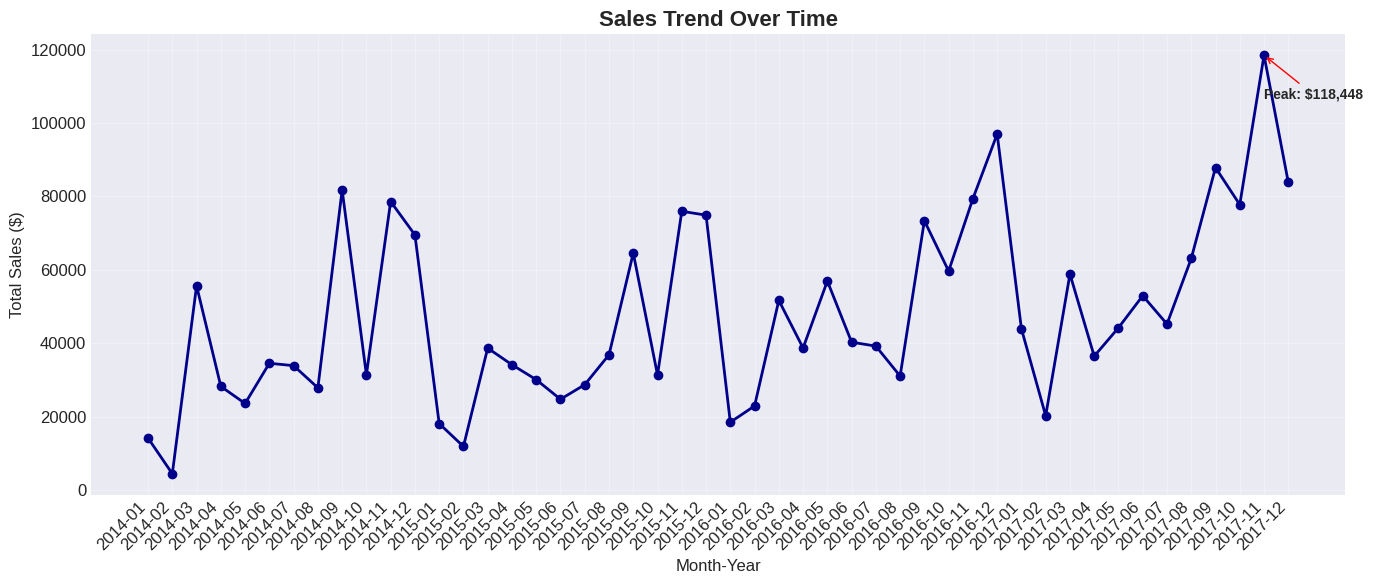

📈 Sales Trend Insights:
   • Highest sales month: 2017-11 ($118,447.82)
   • Average monthly sales: $47,858.35


In [21]:
# Prepare monthly sales data
monthly_sales = df_clean.groupby('Year-Month')['Sales'].sum().reset_index()

# Create line chart
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Year-Month'], monthly_sales['Sales'], 
         marker='o', linewidth=2, markersize=6, color='darkblue')

# Customize chart
plt.title('Sales Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Add value labels on top of peaks
max_idx = monthly_sales['Sales'].idxmax()
plt.annotate(f'Peak: ${monthly_sales.iloc[max_idx]["Sales"]:,.0f}',
             xy=(max_idx, monthly_sales.iloc[max_idx]['Sales']),
             xytext=(max_idx, monthly_sales.iloc[max_idx]['Sales'] * 0.9),
             fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

# Print insights
print(f"📈 Sales Trend Insights:")
print(f"   • Highest sales month: {monthly_sales.iloc[max_idx]['Year-Month']} (${monthly_sales.iloc[max_idx]['Sales']:,.2f})")
print(f"   • Average monthly sales: ${monthly_sales['Sales'].mean():,.2f}")

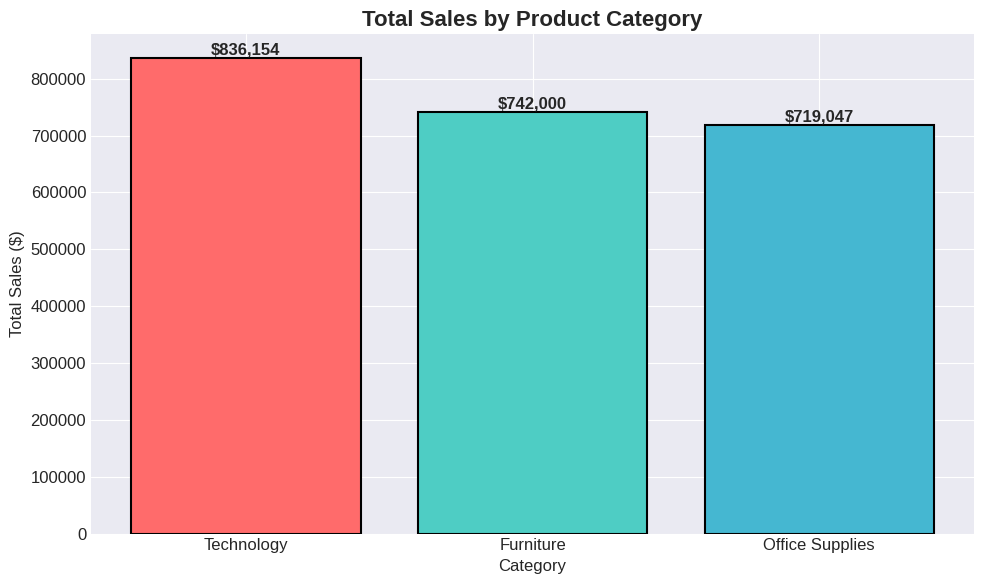

📊 Category Sales Insights:
   • Best selling category: Technology ($836,154.03)
   • % of total sales: 36.4%


In [22]:
# Prepare data
sales_by_cat = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(sales_by_cat.index, sales_by_cat.values, color=colors, edgecolor='black', linewidth=1.5)

# Customize chart
plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=0)

# Add value labels on bars
for bar, value in zip(bars, sales_by_cat.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print insights (FIXED - using .iloc[0] instead of [0])
top_category = sales_by_cat.index[0]
top_sales = sales_by_cat.iloc[0]  # FIXED: use .iloc for position-based access
total_sales = sales_by_cat.sum()

print(f"📊 Category Sales Insights:")
print(f"   • Best selling category: {top_category} (${top_sales:,.2f})")
print(f"   • % of total sales: {(top_sales / total_sales) * 100:.1f}%")

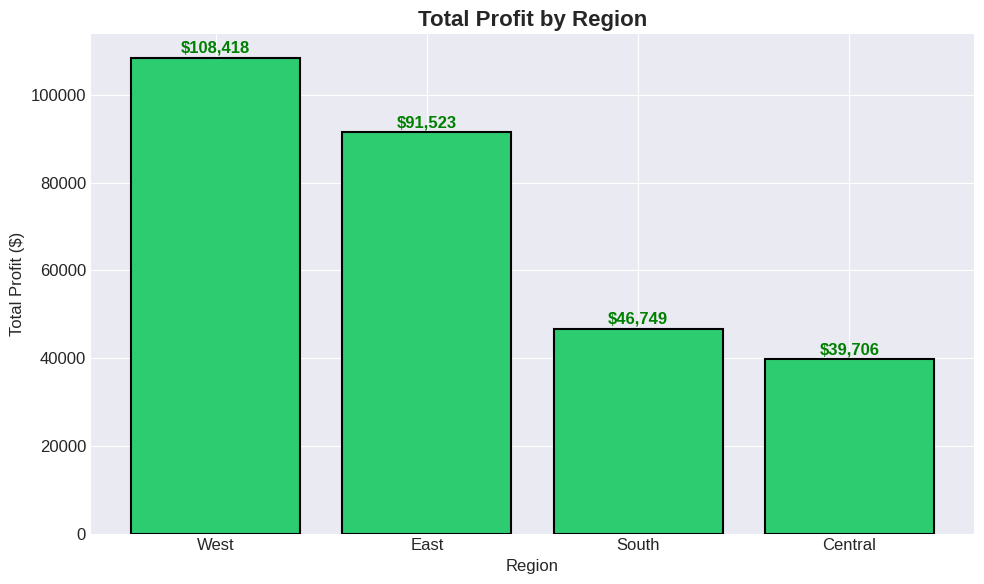

💰 Profit by Region Insights:
   • Most profitable region: West ($108,418.45)
   • Least profitable region: Central ($39,706.36)


In [23]:
# Prepare data
profit_by_region = df_clean.groupby('Region')['Profit'].sum().sort_values(ascending=False)

# Create bar chart with color coding (green for profit, red for loss)
plt.figure(figsize=(10, 6))
colors = ['#2ECC71' if x > 0 else '#E74C3C' for x in profit_by_region.values]
bars = plt.bar(profit_by_region.index, profit_by_region.values, color=colors, edgecolor='black', linewidth=1.5)

# Customize chart
plt.title('Total Profit by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)

# Add value labels
for bar, value in zip(bars, profit_by_region.values):
    color = 'green' if value > 0 else 'red'
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold', color=color)

# Add horizontal line at zero
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Print insights (FIXED - using .iloc)
best_region = profit_by_region.index[0]
best_profit = profit_by_region.iloc[0]
worst_region = profit_by_region.index[-1]
worst_profit = profit_by_region.iloc[-1]

print(f"💰 Profit by Region Insights:")
print(f"   • Most profitable region: {best_region} (${best_profit:,.2f})")
print(f"   • Least profitable region: {worst_region} (${worst_profit:,.2f})")

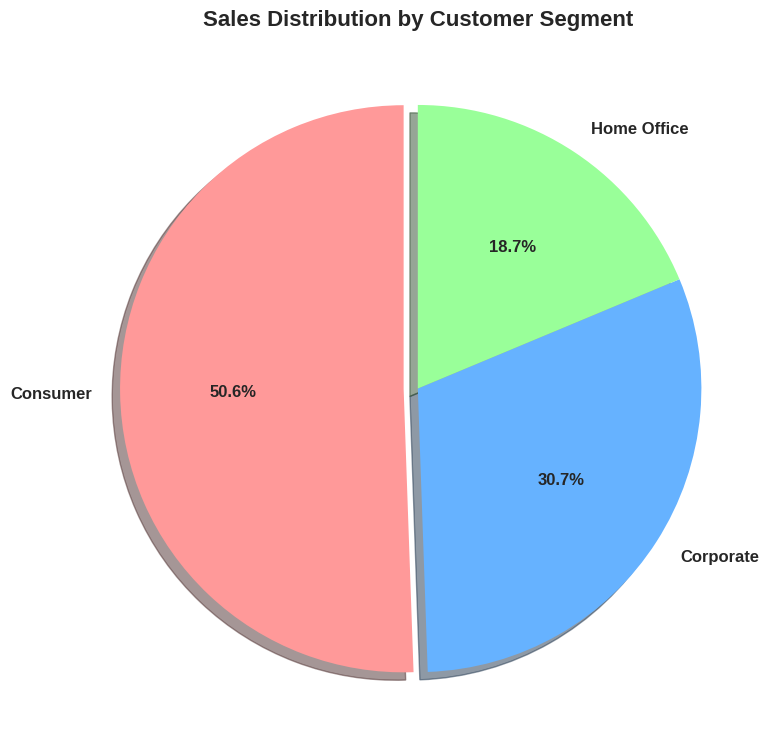

👥 Segment Distribution Insights:
   • Largest segment: Consumer (50.6% of sales)
   • Consumer: $1,161,401.34
   • Corporate: $706,146.37
   • Home Office: $429,653.15


In [24]:
# Prepare data
segment_sales = df_clean.groupby('Segment')['Sales'].sum()

# Create pie chart
plt.figure(figsize=(8, 8))
colors = ['#FF9999', '#66B2FF', '#99FF99']
explode = (0.05, 0, 0)  # Slightly explode the largest slice

# Find largest segment for exploding
largest_idx = segment_sales.values.argmax()
explode = tuple(0.05 if i == largest_idx else 0 for i in range(len(segment_sales)))

plt.pie(segment_sales.values, 
        labels=segment_sales.index,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        shadow=True,
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Sales Distribution by Customer Segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print insights (FIXED - using .iloc)
top_segment = segment_sales.index[0]
top_segment_sales = segment_sales.iloc[0]
total_sales = segment_sales.sum()

print(f"👥 Segment Distribution Insights:")
print(f"   • Largest segment: {top_segment} ({(top_segment_sales/total_sales)*100:.1f}% of sales)")
for segment, sales in segment_sales.items():
    print(f"   • {segment}: ${sales:,.2f}")

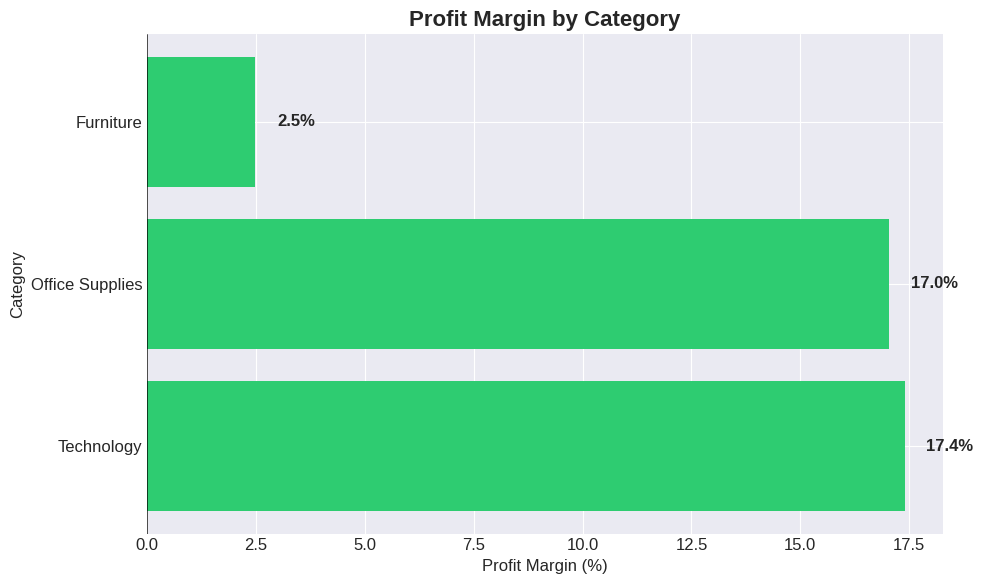

📊 Profit Margin Insights:
   • Technology: 17.4% margin (profitable)
   • Office Supplies: 17.0% margin (profitable)
   • Furniture: 2.5% margin (profitable)


In [25]:
# Calculate profit margin by category - FIXED VERSION
# Method 1: Using agg() instead of apply() - cleaner and no warning
margin_by_cat = df_clean.groupby('Category').agg(
    total_profit=('Profit', 'sum'),
    total_sales=('Sales', 'sum')
)
margin_by_cat['margin'] = (margin_by_cat['total_profit'] / margin_by_cat['total_sales']) * 100
margin_by_cat = margin_by_cat['margin'].sort_values(ascending=False)

# Alternative Method 2 (if you prefer apply with include_groups=False):
# margin_by_cat = df_clean.groupby('Category').apply(
#     lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100,
#     include_groups=False  # This silences the warning
# ).sort_values(ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
colors = ['#2ECC71' if x > 0 else '#E74C3C' for x in margin_by_cat.values]
bars = plt.barh(margin_by_cat.index, margin_by_cat.values, color=colors)

# Customize chart
plt.title('Profit Margin by Category', fontsize=16, fontweight='bold')
plt.xlabel('Profit Margin (%)', fontsize=12)
plt.ylabel('Category', fontsize=12)

# Add value labels
for bar, value in zip(bars, margin_by_cat.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{value:.1f}%', va='center', fontweight='bold')

plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"📊 Profit Margin Insights:")
for cat, margin in margin_by_cat.items():
    status = "profitable" if margin > 0 else "losing money"
    print(f"   • {cat}: {margin:.1f}% margin ({status})")

# Task 8: Analysis & Conclusions

In [26]:
print("="*60)
print("🔍 QUESTION 1: MOST PROFITABLE CATEGORY")
print("="*60)

# Calculate total profit by category
profit_by_category = df_clean.groupby('Category')['Profit'].sum().sort_values(ascending=False)

# FIXED: Calculate profit margin without apply() - direct calculation
sales_by_category = df_clean.groupby('Category')['Sales'].sum()
margin_by_category = (profit_by_category / sales_by_category * 100)

# Create comparison DataFrame
category_analysis = pd.DataFrame({
    'Total Profit': profit_by_category,
    'Profit Margin %': margin_by_category,
    'Total Sales': sales_by_category
})

print(category_analysis)

# FIXED: Use .iloc for position-based access
most_profitable = profit_by_category.index[0]
most_profit_value = profit_by_category.iloc[0]
margin_value = margin_by_category.iloc[0]

print(f"\n✅ CONCLUSION: The most profitable category is {most_profitable}")
print(f"   • Total Profit: ${most_profit_value:,.2f}")
print(f"   • Profit Margin: {margin_value:.1f}%")

# Additional insight: Is highest sales = highest profit?
top_sales_cat = sales_by_category.index[0]
if top_sales_cat != most_profitable:
    print(f"\n💡 Insight: {top_sales_cat} has highest sales but {most_profitable} has highest profit!")
    print(f"   → High sales doesn't always mean high profit")

🔍 QUESTION 1: MOST PROFITABLE CATEGORY
                 Total Profit  Profit Margin %  Total Sales
Category                                                   
Furniture          18451.2728         2.486695  741999.7953
Office Supplies   122490.8008        17.035158  719047.0320
Technology        145454.9481        17.395712  836154.0330

✅ CONCLUSION: The most profitable category is Technology
   • Total Profit: $145,454.95
   • Profit Margin: 2.5%

💡 Insight: Furniture has highest sales but Technology has highest profit!
   → High sales doesn't always mean high profit


In [27]:
print("="*60)
print("🔍 QUESTION 2: LEAST PERFORMING REGION")
print("="*60)

# Calculate profit by region
profit_by_region = df_clean.groupby('Region')['Profit'].sum().sort_values()

# Also check sales by region for context
sales_by_region = df_clean.groupby('Region')['Sales'].sum()

# FIXED: Calculate profit margin without apply() - direct calculation
margin_by_region = (profit_by_region / sales_by_region * 100)

region_analysis = pd.DataFrame({
    'Total Profit': profit_by_region,
    'Total Sales': sales_by_region,
    'Profit Margin %': margin_by_region
})

print(region_analysis)

# FIXED: Use .iloc for position-based access
least_profitable = profit_by_region.index[0]
least_profit_value = profit_by_region.iloc[0]
least_margin_value = margin_by_region.iloc[0]

print(f"\n✅ CONCLUSION: The least performing region is {least_profitable}")
print(f"   • Total Profit: ${least_profit_value:,.2f}")
print(f"   • Profit Margin: {least_margin_value:.1f}%")

# Analyze why this region is underperforming
print(f"\n🔎 DEEP DIVE: Why is {least_profitable} underperforming?")

# Check product categories in this region
region_data = df_clean[df_clean['Region'] == least_profitable]
cat_profit = region_data.groupby('Category')['Profit'].sum()
print(f"\n   Profit by category in {least_profitable}:")
for cat, profit in cat_profit.items():
    status = "✅" if profit > 0 else "❌"
    print(f"   {status} {cat}: ${profit:,.2f}")

# Check top losing products
losing_products = region_data[region_data['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().sort_values().head(3)
print(f"\n   Top 3 loss-making sub-categories in {least_profitable}:")
for product, loss in losing_products.items():
    print(f"   ❌ {product}: ${loss:,.2f} loss")

🔍 QUESTION 2: LEAST PERFORMING REGION
         Total Profit  Total Sales  Profit Margin %
Region                                             
Central    39706.3625  501239.8908         7.921629
East       91522.7800  678781.2400        13.483399
South      46749.4303  391721.9050        11.934342
West      108418.4489  725457.8245        14.944831

✅ CONCLUSION: The least performing region is Central
   • Total Profit: $39,706.36
   • Profit Margin: 7.9%

🔎 DEEP DIVE: Why is Central underperforming?

   Profit by category in Central:
   ❌ Furniture: $-2,871.05
   ✅ Office Supplies: $8,879.98
   ✅ Technology: $33,697.43

   Top 3 loss-making sub-categories in Central:
   ❌ Binders: $-21,909.40 loss
   ❌ Appliances: $-8,629.64 loss
   ❌ Tables: $-6,568.36 loss


In [28]:
print("="*60)
print("🔍 QUESTION 3: PATTERNS BETWEEN SALES AND PROFIT")
print("="*60)

# Calculate correlation
correlation = df_clean['Sales'].corr(df_clean['Profit'])
print(f"📈 Correlation between Sales and Profit: {correlation:.3f}")
print("   (1.0 = perfect positive, -1.0 = perfect negative, 0 = no relationship)")

# Check if high sales always means high profit
high_sales = df_clean.nlargest(10, 'Sales')
high_profit = df_clean.nlargest(10, 'Profit')

print(f"\n📊 Pattern Analysis:")
print(f"   • Top 10 sales orders average profit: ${high_sales['Profit'].mean():,.2f}")
print(f"   • Top 10 profit orders average sales: ${high_profit['Sales'].mean():,.2f}")

# FIXED: Add observed=True to suppress categorical dtype warning
df_clean['Discount Bin'] = pd.cut(df_clean['Discount'], 
                                   bins=[-0.01, 0, 0.1, 0.2, 0.5, 1], 
                                   labels=['No Discount', '0-10%', '10-20%', '20-50%', '50%+'])

discount_impact = df_clean.groupby('Discount Bin', observed=True).agg({
    'Profit': 'mean',
    'Sales': 'mean',
    'Quantity': 'mean'
})

print(f"\n💰 Impact of Discount on Average Profit:")
print(discount_impact)

# Key insights
loss_orders = df_clean[df_clean['Profit'] < 0]
profitable_orders = df_clean[df_clean['Profit'] > 0]

print(f"\n💡 KEY PATTERNS IDENTIFIED:")
print(f"   1. {'Positive' if correlation > 0 else 'Negative'} correlation between sales and profit")
if correlation < 0.5:
    print(f"   2. Sales alone doesn't guarantee profit - other factors matter")
print(f"   3. {len(loss_orders):,} orders ({len(loss_orders)/len(df_clean)*100:.1f}%) are losing money")
print(f"   4. Average discount on loss-making orders: {loss_orders['Discount'].mean():.1%}")
print(f"   5. Average discount on profitable orders: {profitable_orders['Discount'].mean():.1%}")

🔍 QUESTION 3: PATTERNS BETWEEN SALES AND PROFIT
📈 Correlation between Sales and Profit: 0.479
   (1.0 = perfect positive, -1.0 = perfect negative, 0 = no relationship)

📊 Pattern Analysis:
   • Top 10 sales orders average profit: $3,813.17
   • Top 10 profit orders average sales: $9,849.13

💰 Impact of Discount on Average Profit:
                  Profit       Sales  Quantity
Discount Bin                                  
No Discount    66.900292  226.742074  3.807211
0-10%          96.055074  578.397351  3.968085
10-20%         24.738824  213.575867  3.736317
20-50%       -109.528873  555.943039  3.772812
50%+          -89.438144   75.033572  3.912383

💡 KEY PATTERNS IDENTIFIED:
   1. Positive correlation between sales and profit
   2. Sales alone doesn't guarantee profit - other factors matter
   3. 1,871 orders (18.7%) are losing money
   4. Average discount on loss-making orders: 48.1%
   5. Average discount on profitable orders: 8.1%


In [29]:
print("="*60)
print(" QUESTION 4: IMPORTANT TRENDS OVER TIME")
print("="*60)

# Year-over-year growth
yearly_sales = df_clean.groupby('Year')['Sales'].sum()
yearly_profit = df_clean.groupby('Year')['Profit'].sum()

print(" YEARLY TRENDS:")
for year in yearly_sales.index:
    print(f"   {year}:")
    print(f"      Sales: ${yearly_sales[year]:,.2f}")
    print(f"      Profit: ${yearly_profit[year]:,.2f}")

# Calculate growth rates
if len(yearly_sales) > 1:
    sales_growth = ((yearly_sales.iloc[-1] - yearly_sales.iloc[0]) / yearly_sales.iloc[0]) * 100
    profit_growth = ((yearly_profit.iloc[-1] - yearly_profit.iloc[0]) / yearly_profit.iloc[0]) * 100
    print(f"\n Overall Growth:")
    print(f"   • Sales growth: {sales_growth:.1f}%")
    print(f"   • Profit growth: {profit_growth:.1f}%")

# Seasonal patterns
monthly_avg = df_clean.groupby('Month')['Sales'].mean()
best_month = monthly_avg.idxmax()
worst_month = monthly_avg.idxmin()

print(f"\n SEASONAL PATTERNS:")
print(f"   • Best month (average): Month {best_month} (${monthly_avg[best_month]:,.2f})")
print(f"   • Worst month (average): Month {worst_month} (${monthly_avg[worst_month]:,.2f})")

# Segment trends over time
segment_yearly = df_clean.groupby(['Year', 'Segment'])['Sales'].sum().unstack()
print(f"\n SEGMENT TRENDS:")
print(segment_yearly)

# Final recommendations
print("\n" + "="*60)
print(" FINAL RECOMMENDATIONS")
print("="*60)

print("\n1. Focus on profitable categories:")
print(f"   → Prioritize {most_profitable} category")

print(f"\n2. Address issues in {least_profitable} region:")
print(f"   → Review discount strategy in this region")
print(f"   → Investigate loss-making sub-categories")

print("\n3. Optimize discount strategy:")
print(f"   → Discounts >20% show negative impact on profit")
print(f"   → Consider removing or reducing high discounts")

print("\n4. Leverage seasonal patterns:")
print(f"   → Increase inventory before Month {best_month}")
print(f"   → Run promotions during slow Month {worst_month}")

print("\n5. Customer segment focus:")
print(f"   → {top_segment} segment drives most sales - nurture them")

 QUESTION 4: IMPORTANT TRENDS OVER TIME
 YEARLY TRENDS:
   2014:
      Sales: $484,247.50
      Profit: $49,543.97
   2015:
      Sales: $470,532.51
      Profit: $61,618.60
   2016:
      Sales: $609,205.60
      Profit: $81,795.17
   2017:
      Sales: $733,215.26
      Profit: $93,439.27

 Overall Growth:
   • Sales growth: 51.4%
   • Profit growth: 88.6%

 SEASONAL PATTERNS:
   • Best month (average): Month 3 ($294.55)
   • Worst month (average): Month 2 ($199.17)

 SEGMENT TRENDS:
Segment     Consumer    Corporate  Home Office
Year                                          
2014     266096.8126  128434.8737   89715.8118
2015     266535.9333  128757.3069   75239.2688
2016     296863.8992  207106.3618  105235.3370
2017     331904.6999  241847.8244  159462.7309

 FINAL RECOMMENDATIONS

1. Focus on profitable categories:
   → Prioritize Technology category

2. Address issues in Central region:
   → Review discount strategy in this region
   → Investigate loss-making sub-categories

3. 